# Robust fixed-LR PCA-MNIST Muon family

This notebook reproduces the four robust configurations identified around the original PCA-MNIST experiment. It uses the same fixed non-Gaussian problem and plots, on one common 300-step horizon:

1. aggregated **cycle-mean loss**;
2. phase-averaged **mean teacher-subspace alignment**;
3. phase-averaged **minimum/weakest-direction alignment**.

All four configurations use full-batch exact-polar Muon, a fixed learning rate, a fixed head, no schedule, no controller, and no momentum. The common evaluation window is steps $40$--$200$.

In [1]:
from pathlib import Path
import copy
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "mnist_pca_muon.py").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import mnist_pca_muon as mpm
import robust_family as rf
import pandas as pd
from IPython.display import Image, display

print("Bundle root:", ROOT)

Bundle root: /mnt/data/mnist_pca_muon_lightweight_robust_family_bundle/mnist_pca_muon_lightweight


## 1. Parameters

In [2]:
# ------------------------ EDIT THIS CELL ------------------------
# "frozen" exactly reproduces the reported fixed problem without rebuilding PCA.
# "rebuild" reconstructs the problem from data/mnist_train_uint8.npz.
PROBLEM_MODE = "frozen"

# Use "confirmation" for the exact 30 fresh robust-family seeds, or
# "development" for a faster five-seed run.
FAMILY_SEED_GROUP = "development"

FAMILY_STEPS = 300
FAMILY_WINDOW = (40, 200)
FAMILY_LOG_EVERY = 10
FAMILY_THREADS = 1
FAMILY_BOOTSTRAP_REPETITIONS = 1_000
FORCE_RERUN = True
FORCE_REBUILD_PROBLEM = False

# The four confirmed configurations. The head multiplier h means that every
# fixed output coefficient equals h / sqrt(p), where p is the PCA dimension.
FAMILY_CONFIGS = copy.deepcopy(rf.ROBUST_FAMILY_CONFIGS)

# Examples of safe edits:
# FAMILY_CONFIGS[0]["learning_rate"] = 0.55
# FAMILY_CONFIGS.append({
#     "config_id": "custom_w70_e050_h100",
#     "label": r"$r_s=70,\ \eta=0.50,\ h=1.00$",
#     "width": 70,
#     "learning_rate": 0.50,
#     "head_multiplier": 1.00,
# })
# FAMILY_STEPS = 400
# FAMILY_WINDOW = (40, 240)

FROZEN_PROBLEM = ROOT / "data" / "fixed_problem_reproduction.npz"
LIGHTWEIGHT_MNIST = ROOT / "data" / "mnist_train_uint8.npz"
FAMILY_OUTPUT_ROOT = ROOT / "notebook_outputs" / "robust_family_300"

base_config = copy.deepcopy(mpm.DEFAULT_CONFIG)
base_config["data"]["mnist_source"] = str(LIGHTWEIGHT_MNIST)
base_config["output"]["output_root"] = str(FAMILY_OUTPUT_ROOT)

family_seeds = (
    rf.ROBUST_FAMILY_CONFIRMATION_SEEDS
    if FAMILY_SEED_GROUP == "confirmation"
    else rf.ROBUST_FAMILY_DEVELOPMENT_SEEDS
)

config_table = pd.DataFrame([
    {
        "config_id": spec["config_id"],
        "width": spec["width"],
        "eta": spec["learning_rate"],
        "head_multiplier": spec["head_multiplier"],
        "head_value_when_p100": spec["head_multiplier"] / 10.0,
    }
    for spec in FAMILY_CONFIGS
])
print("Seed group:", FAMILY_SEED_GROUP, "| seeds:", len(family_seeds))
print("Steps:", FAMILY_STEPS, "| window:", FAMILY_WINDOW)
display(config_table)

Seed group: development | seeds: 5
Steps: 300 | window: (40, 200)


,config_id,width,eta,head_multiplier,head_value_when_p100
0,C5_w60_e060_h100,60,0.6,1.00,0.100
1,C3_w50_e060_h125,50,0.6,1.25,0.125
2,C4_w60_e050_h100,60,0.5,1.00,0.100
3,C2_w50_e050_h125,50,0.5,1.25,0.125


## 2. Prepare or load the fixed problem

In [3]:
if PROBLEM_MODE == "frozen":
    if not FROZEN_PROBLEM.is_file():
        raise FileNotFoundError(FROZEN_PROBLEM)
    problem_path = FROZEN_PROBLEM
else:
    rebuild_config = copy.deepcopy(base_config)
    rebuild_config["output"]["output_root"] = str(ROOT / "notebook_outputs")
    rebuild_config["output"]["experiment_name"] = "robust_family_rebuilt_problem"
    rebuild_config["data"].update(
        n_train=5000,
        pca_dim=100,
        whiten=True,
        problem_seed=2026,
        allowed_digits=None,
    )
    rebuild_config["teacher"].update(rank=4, seed=5, head_value=1.0)
    if not LIGHTWEIGHT_MNIST.is_file():
        raise FileNotFoundError(LIGHTWEIGHT_MNIST)
    problem_path = mpm.prepare_problem(
        rebuild_config,
        force=FORCE_REBUILD_PROBLEM,
    )

problem = mpm.load_problem(problem_path)
print("Problem:", problem_path)
print("X:", problem["X"].shape)
print("Teacher basis:", problem["U_teacher"].shape)
assert problem["X"].shape == (5000, 100)
assert problem["U_teacher"].shape == (100, 4)

Problem: /mnt/data/mnist_pca_muon_lightweight_robust_family_bundle/mnist_pca_muon_lightweight/data/fixed_problem_reproduction.npz
X: (5000, 100)
Teacher basis: (100, 4)


## 3. Run all four fixed-LR configurations

In [4]:
run_outputs = rf.run_family(
    base_config,
    problem_path,
    FAMILY_OUTPUT_ROOT,
    configs=FAMILY_CONFIGS,
    seeds=family_seeds,
    steps=FAMILY_STEPS,
    window=FAMILY_WINDOW,
    log_every=FAMILY_LOG_EVERY,
    threads=FAMILY_THREADS,
    force=FORCE_RERUN,
)
run_outputs

01/4 C5_w60_e060_h100 seed 01/5=5: 0.99s


01/4 C5_w60_e060_h100 seed 02/5=11: 0.94s


01/4 C5_w60_e060_h100 seed 03/5=23: 0.94s


01/4 C5_w60_e060_h100 seed 04/5=37: 1.11s


01/4 C5_w60_e060_h100 seed 05/5=41: 0.95s


...

04/4 C2_w50_e050_h125 seed 02/5=11: 0.90s


04/4 C2_w50_e050_h125 seed 03/5=23: 0.91s


04/4 C2_w50_e050_h125 seed 04/5=37: 0.91s


04/4 C2_w50_e050_h125 seed 05/5=41: 0.92s


{'C5_w60_e060_h100': PosixPath('/mnt/data/mnist_pca_muon_lightweight_robust_family_bundle/mnist_pca_muon_lightweight/notebook_outputs/robust_family_300/C5_w60_e060_h100/raw'),
 'C3_w50_e060_h125': PosixPath('/mnt/data/mnist_pca_muon_lightweight_robust_family_bundle/mnist_pca_muon_lightweight/notebook_outputs/robust_family_300/C3_w50_e060_h125/raw'),
 'C4_w60_e050_h100': PosixPath('/mnt/data/mnist_pca_muon_lightweight_robust_family_bundle/mnist_pca_muon_lightweight/notebook_outputs/robust_family_300/C4_w60_e050_h100/raw'),
 'C2_w50_e050_h125': PosixPath('/mnt/data/mnist_pca_muon_lightweight_robust_family_bundle/mnist_pca_muon_lightweight/notebook_outputs/robust_family_300/C2_w50_e050_h125/raw')}

## 4. Aggregate the cycle loss, mean alignment, and minimum alignment

In [5]:
analysis_outputs = rf.analyze_family(
    FAMILY_OUTPUT_ROOT,
    configs=FAMILY_CONFIGS,
    seeds=family_seeds,
    steps=FAMILY_STEPS,
    window=FAMILY_WINDOW,
    log_every=FAMILY_LOG_EVERY,
    bootstrap_repetitions=FAMILY_BOOTSTRAP_REPETITIONS,
)

summary = pd.read_csv(analysis_outputs["summary"])
display(summary[[
    "config_id",
    "width",
    "learning_rate",
    "head_multiplier",
    "n_seeds",
    "median_loss_change",
    "median_mean_phaseavg_start",
    "median_mean_phaseavg_end",
    "median_mean_phaseavg_gain",
    "median_min_phaseavg_start",
    "median_min_phaseavg_end",
    "median_min_phaseavg_gain",
    "median_rho2",
    "median_r2",
    "strict_seeds",
]])

,config_id,width,learning_rate,head_multiplier,n_seeds,median_loss_change,median_mean_phaseavg_start,median_mean_phaseavg_end,median_mean_phaseavg_gain,median_min_phaseavg_start,median_min_phaseavg_end,median_min_phaseavg_gain,median_rho2,median_r2,strict_seeds
0,C5_w60_e060_h100,60,0.6,1.00,5,-0.020844,0.523624,0.776987,0.285290,0.037095,0.455898,0.404513,0.999989,0.161725,5
1,C3_w50_e060_h125,50,0.6,1.25,5,-0.029411,0.512560,0.829324,0.306953,0.070281,0.722865,0.577245,0.999982,0.180858,5
2,C4_w60_e050_h100,60,0.5,1.00,5,0.003189,0.567622,0.778639,0.211016,0.022844,0.533843,0.421667,0.999983,0.140724,5
3,C2_w50_e050_h125,50,0.5,1.25,5,0.020852,0.556875,0.806519,0.260917,0.119398,0.669095,0.549697,0.999962,0.168704,5


/mnt/data/mnist_pca_muon_lightweight_robust_family_bundle/mnist_pca_muon_lightweight/notebook_outputs/robust_family_300/family_analysis/robust_family_cycle_mean_loss.png


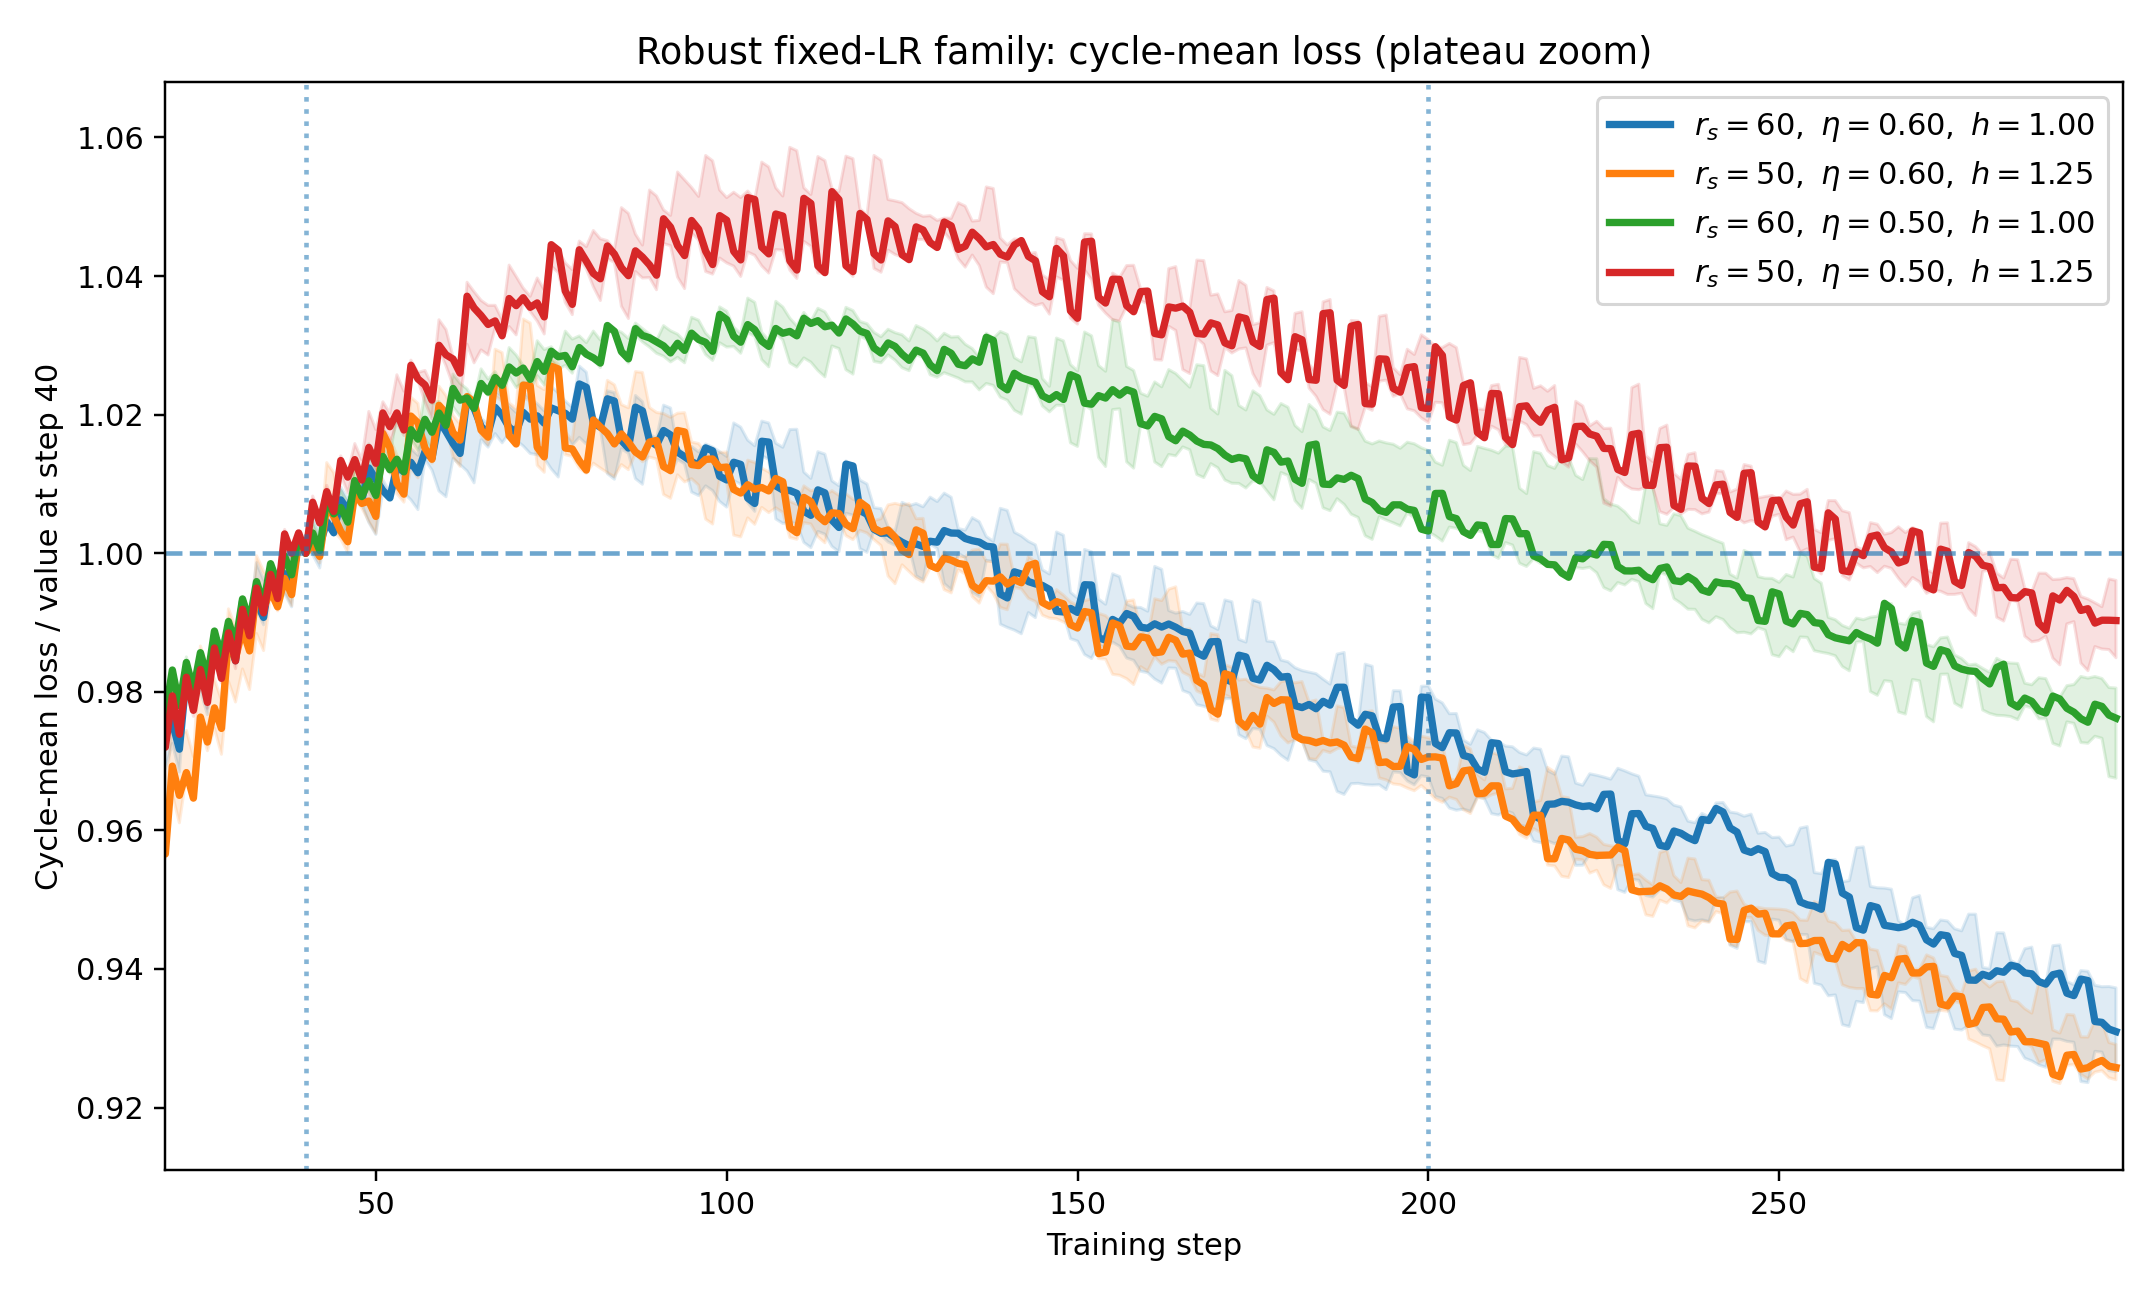

/mnt/data/mnist_pca_muon_lightweight_robust_family_bundle/mnist_pca_muon_lightweight/notebook_outputs/robust_family_300/family_analysis/robust_family_mean_alignment.png


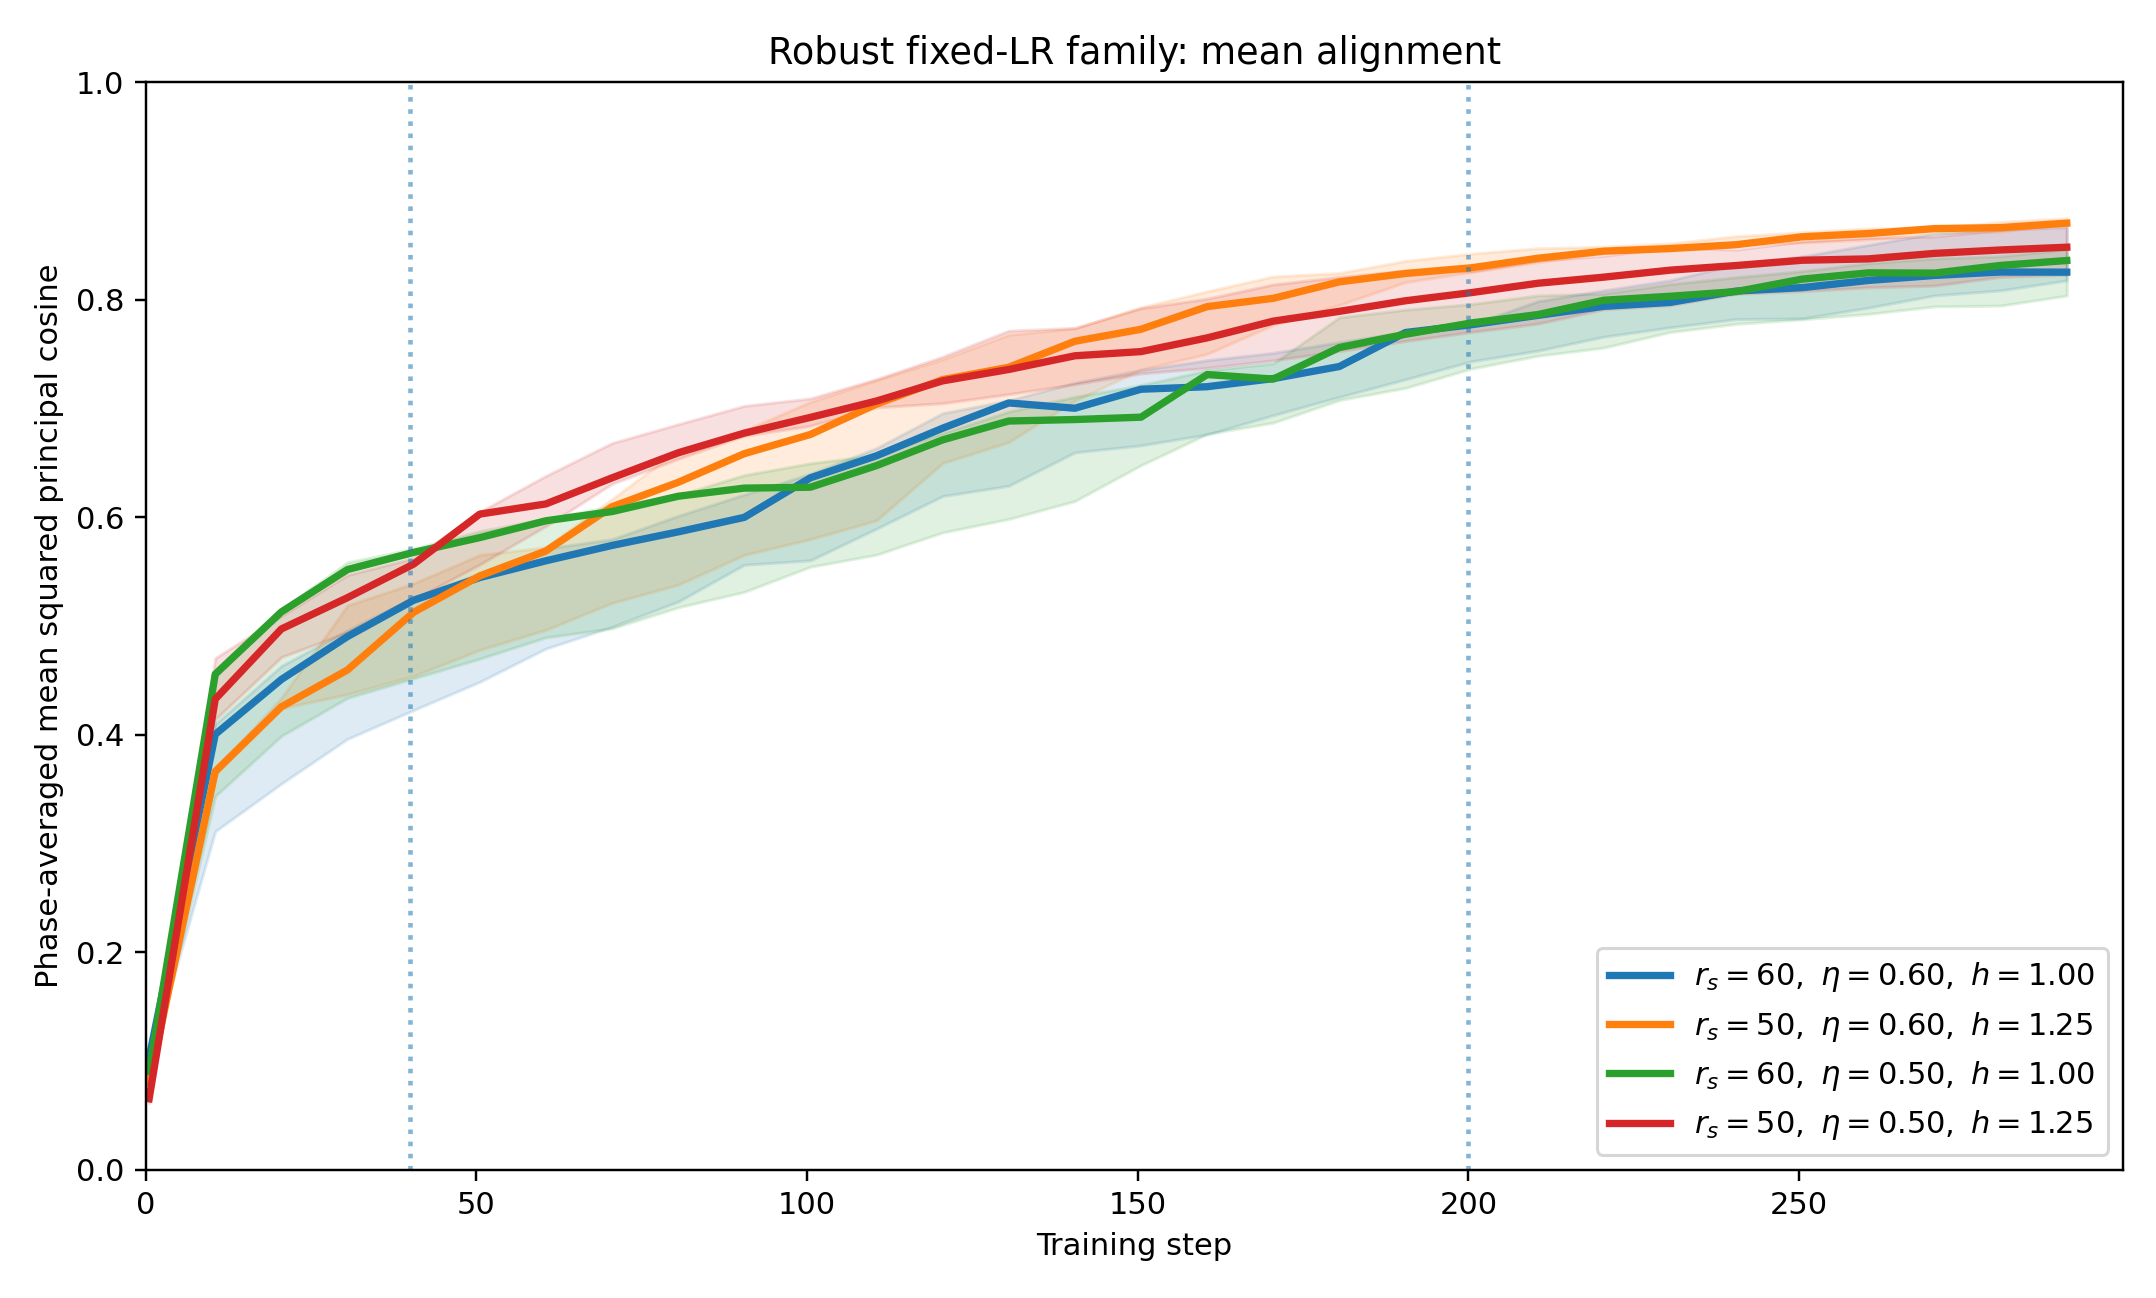

/mnt/data/mnist_pca_muon_lightweight_robust_family_bundle/mnist_pca_muon_lightweight/notebook_outputs/robust_family_300/family_analysis/robust_family_min_alignment.png


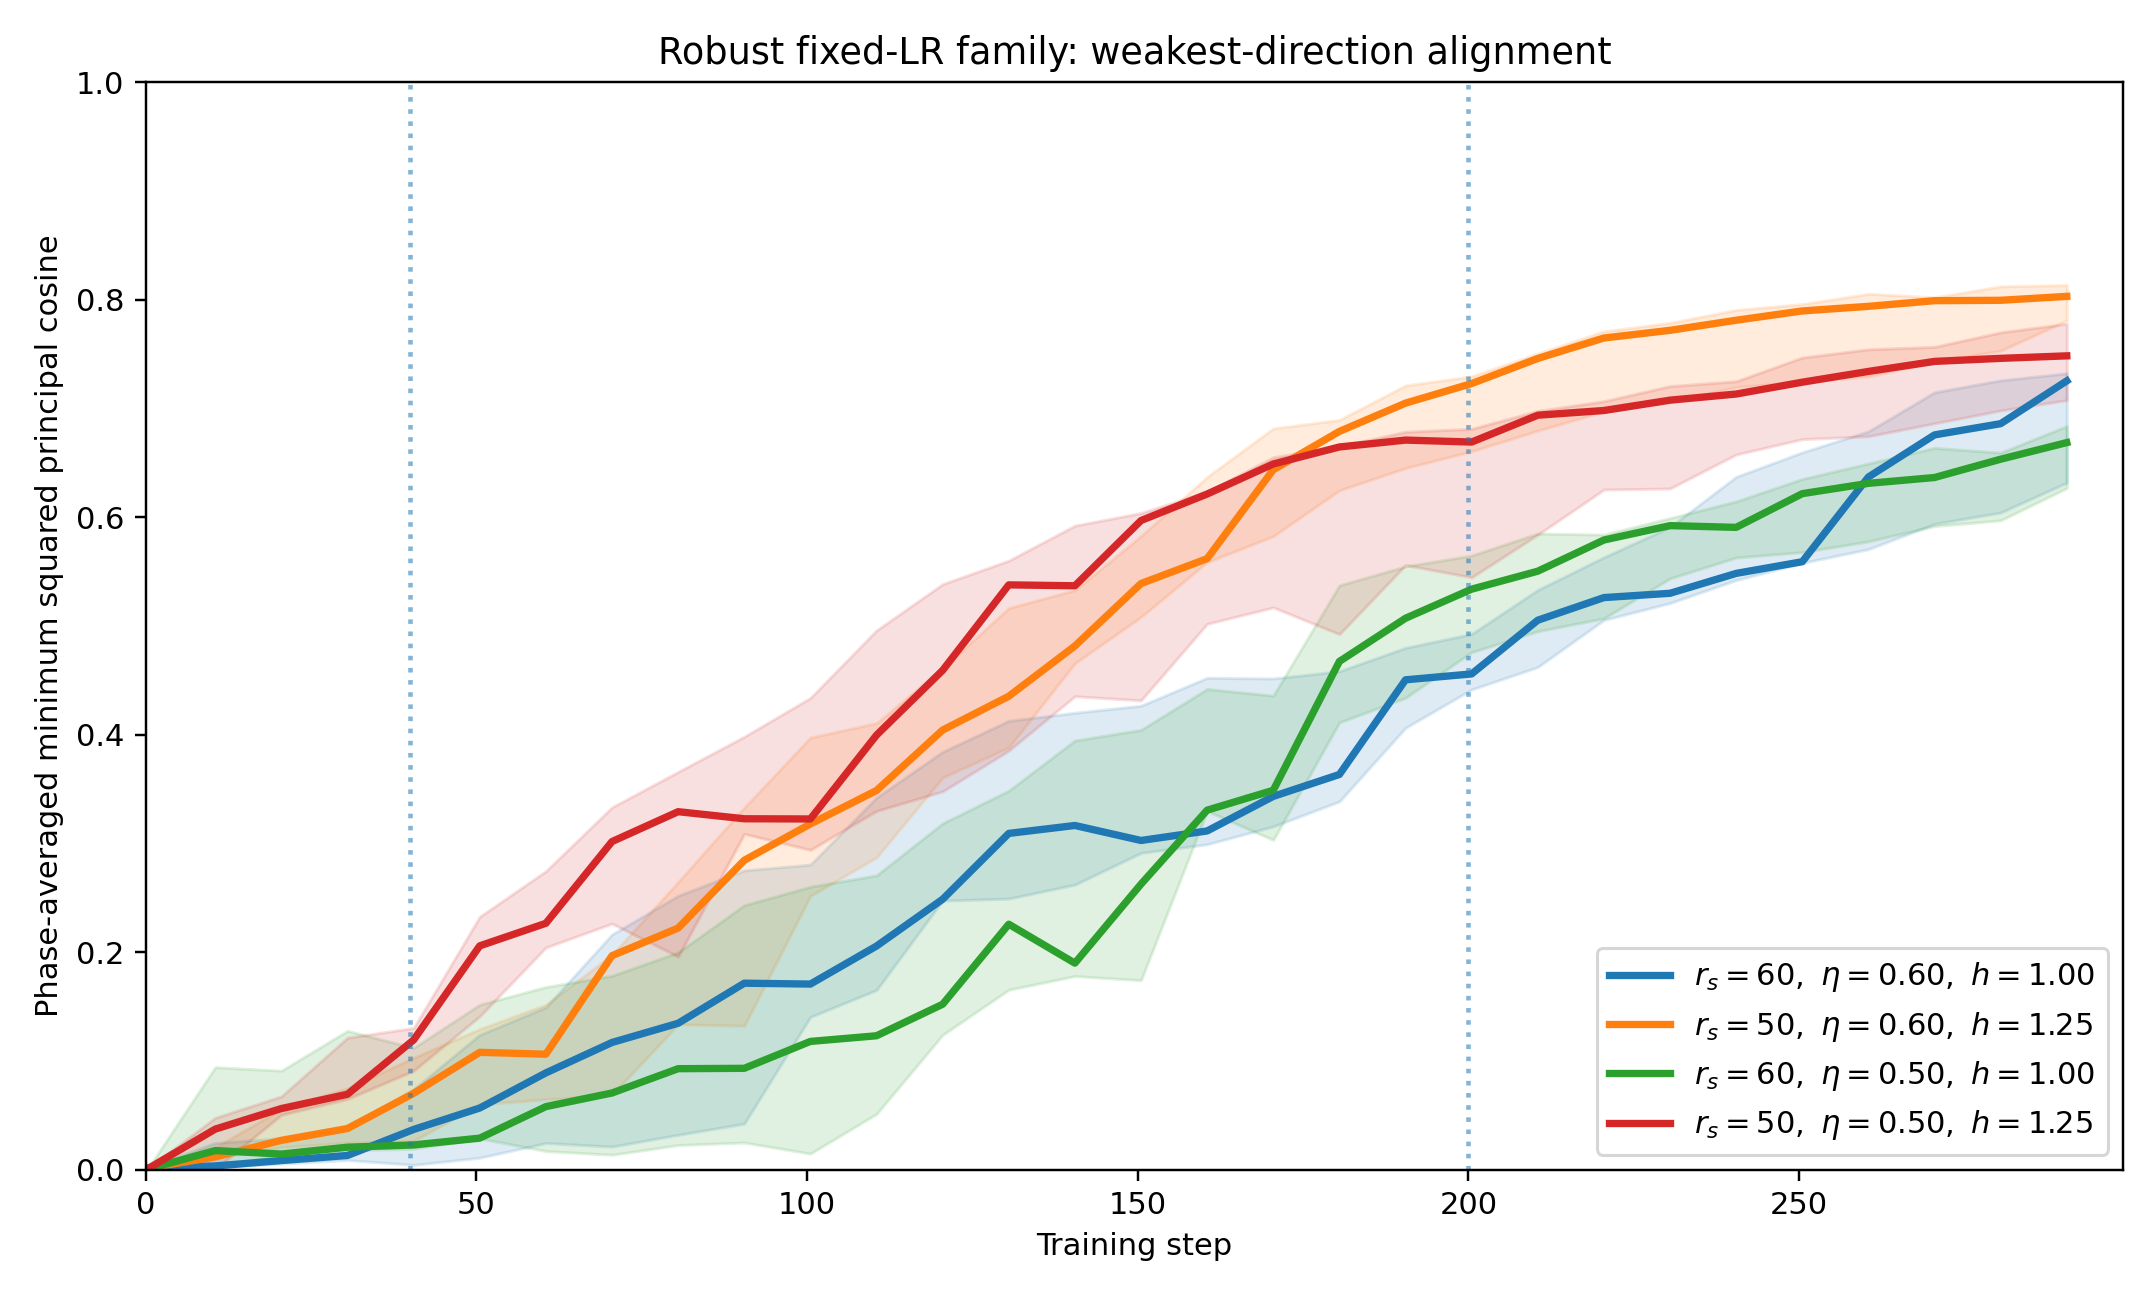

In [6]:
for key in ["cycle_plot", "mean_plot", "min_plot"]:
    print(analysis_outputs[key])
    display(Image(filename=str(analysis_outputs[key])))

## 5. Interpretation

The plots deliberately stop at 300 steps. This keeps the visually clean regime in view:

- the cycle mean is nearly flat or mildly rising/falling on steps $40$--$200$;
- all four configurations exhibit visible mean-alignment growth;
- the weakest teacher direction also improves substantially;
- both members of the parameter two-cycle are averaged before plotting alignment.

To reproduce the 30-seed numbers from the robust-family report, keep `FAMILY_SEED_GROUP = "confirmation"`. Use `"development"` for a quick five-seed exploratory run.

## 6. Optional: inspect the included reference outputs

,config_id,width,learning_rate,head_multiplier,n_seeds,median_loss_change,median_mean_phaseavg_start,median_mean_phaseavg_end,median_mean_phaseavg_gain,median_min_phaseavg_gain,median_rho2,median_r2,strict_seeds
0,C5_w60_e060_h100,60,0.6,1.00,30,-0.024202,0.487891,0.751592,0.271135,0.419260,0.999989,0.155965,29
1,C3_w50_e060_h125,50,0.6,1.25,30,-0.033448,0.514132,0.806574,0.271124,0.487499,0.999979,0.187416,28
2,C4_w60_e050_h100,60,0.5,1.00,30,0.008975,0.534611,0.737735,0.201647,0.340193,0.999986,0.143459,27
3,C2_w50_e050_h125,50,0.5,1.25,30,0.018558,0.557387,0.770215,0.200896,0.337909,0.999969,0.170132,26


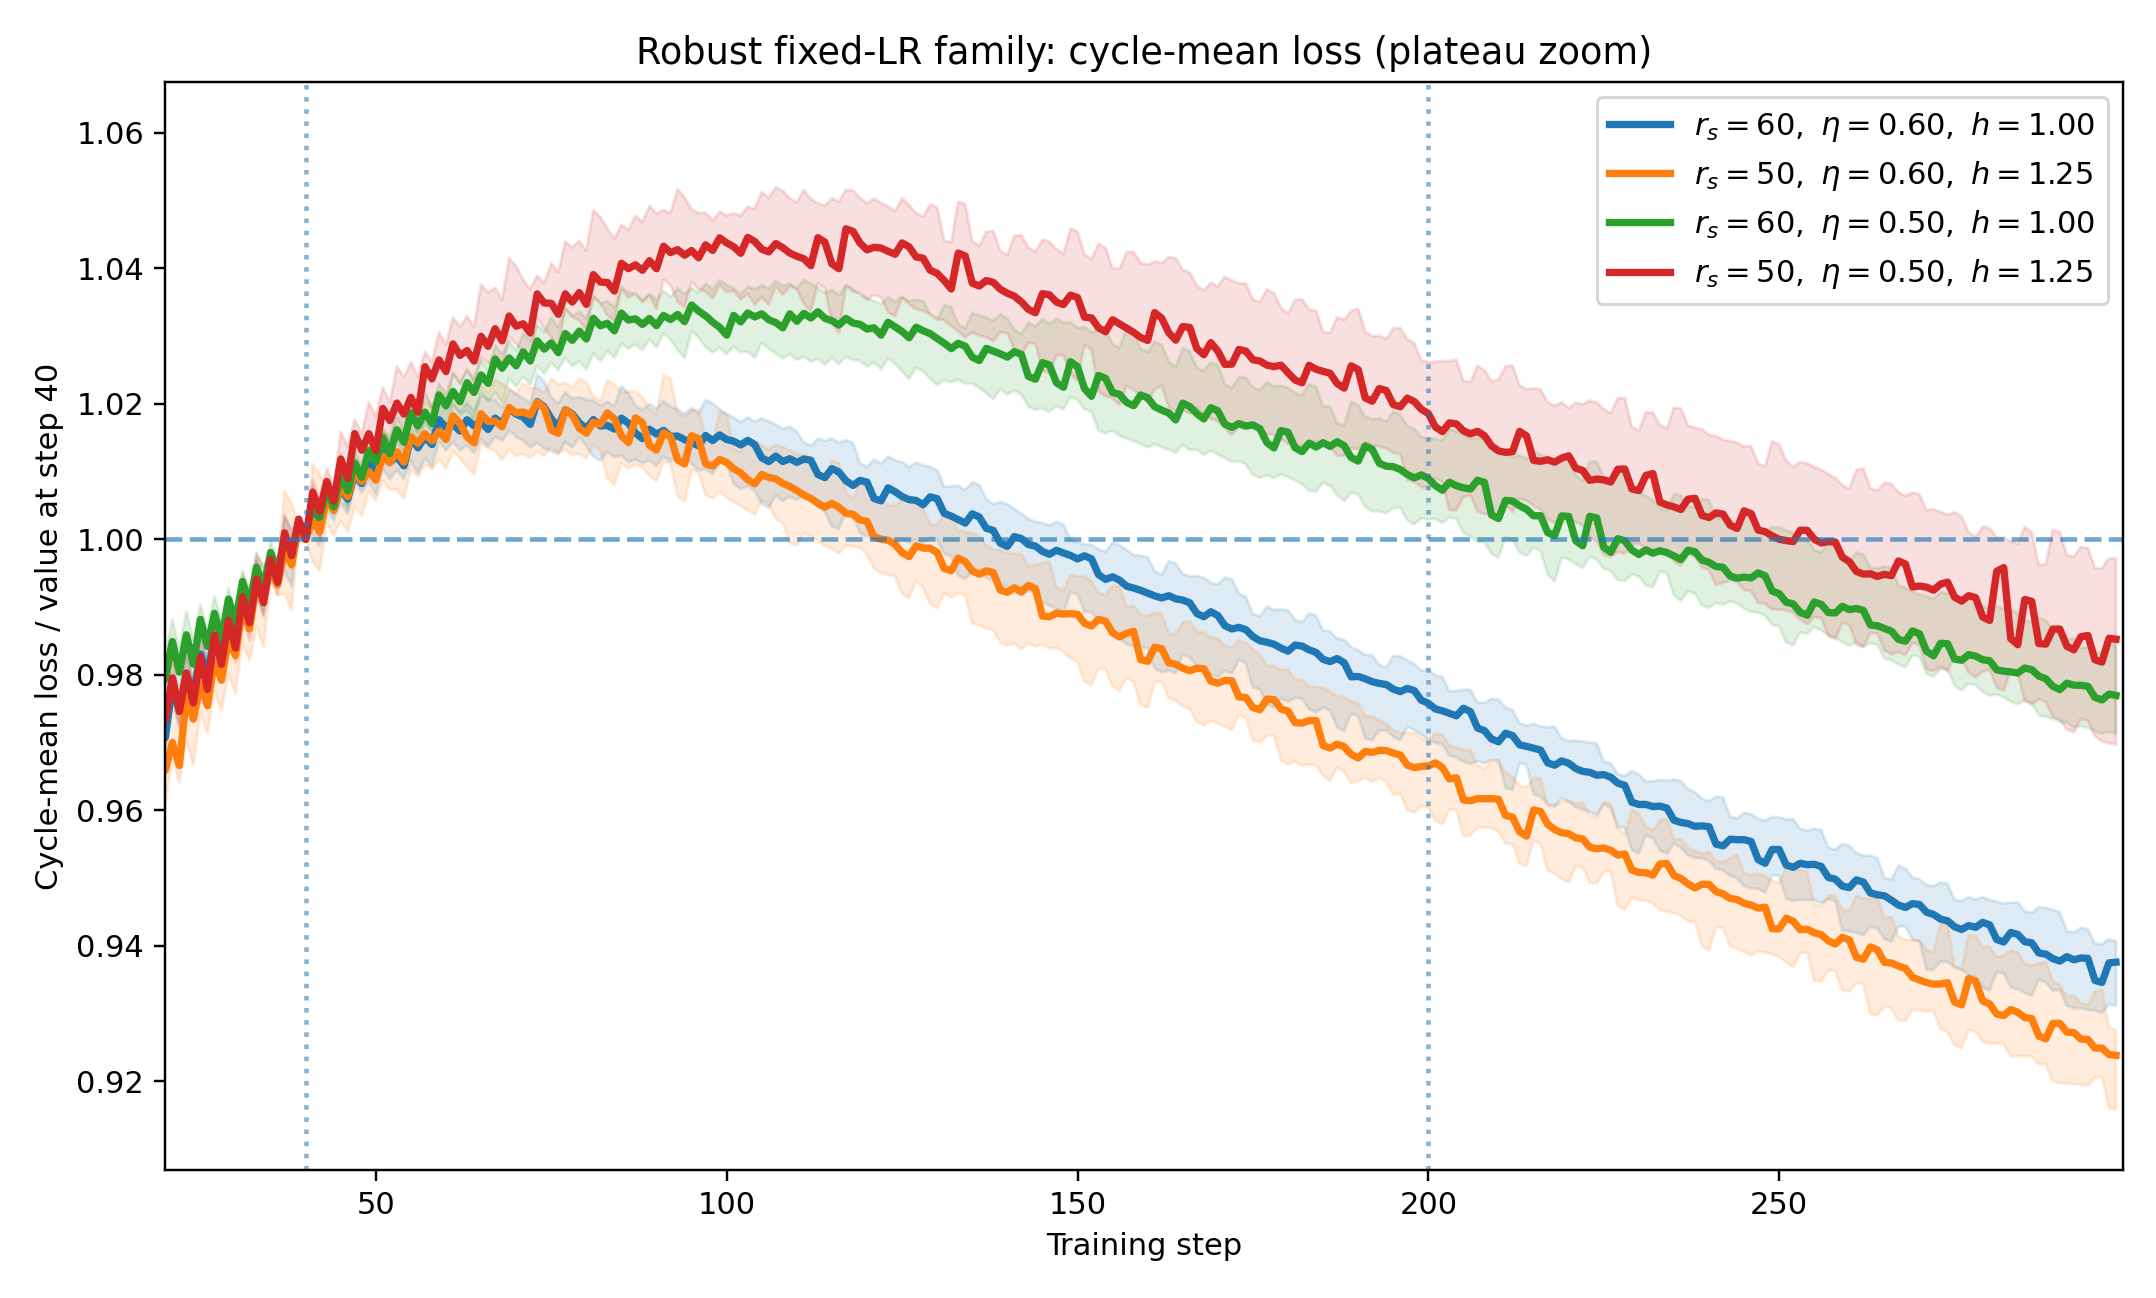

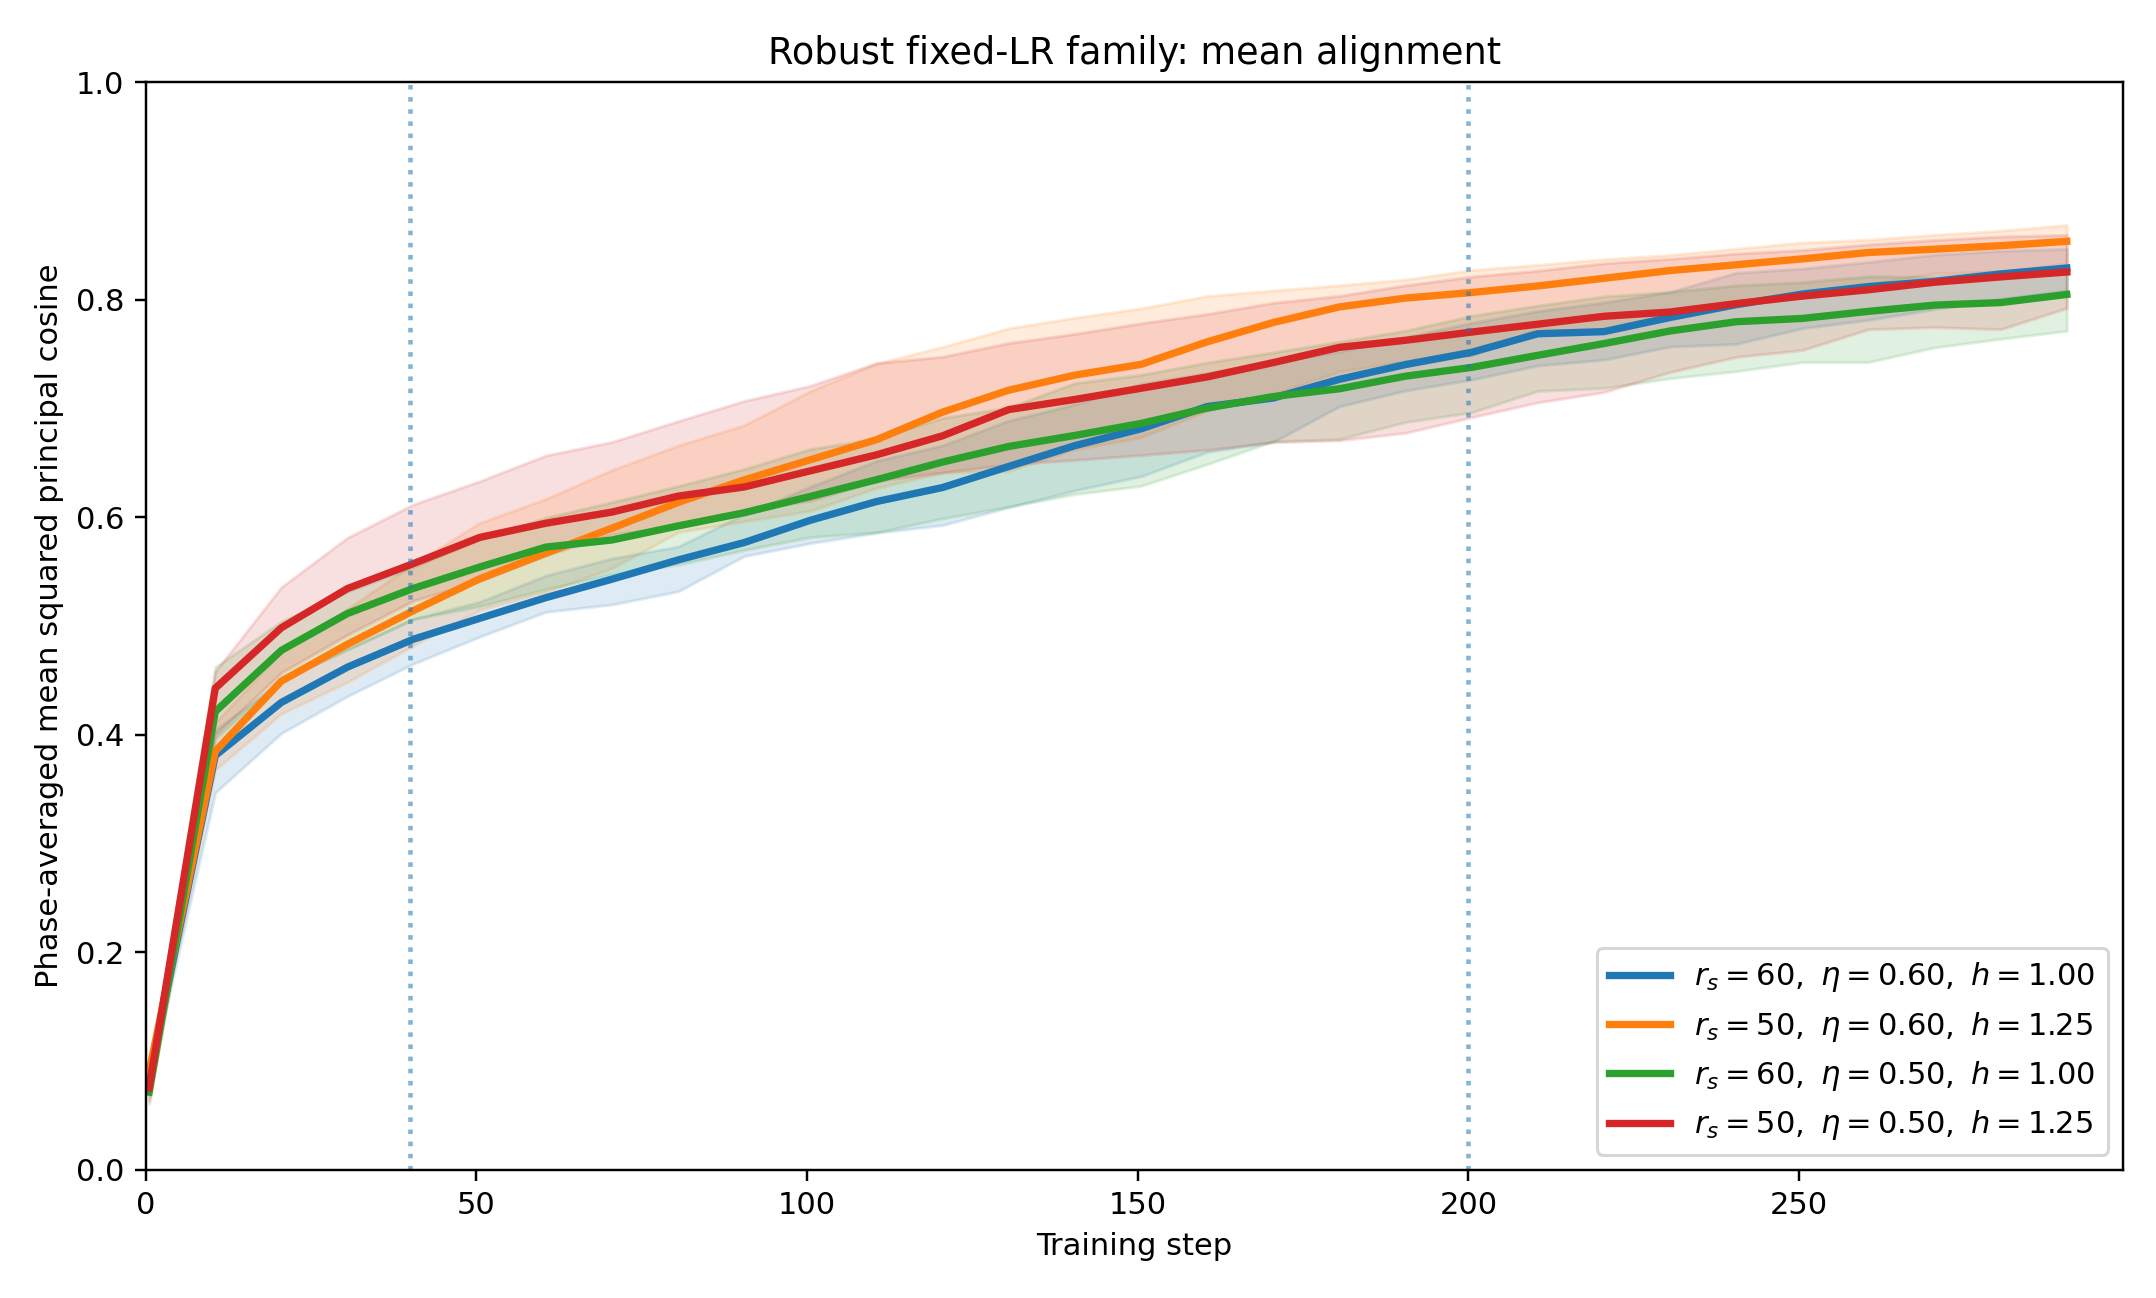

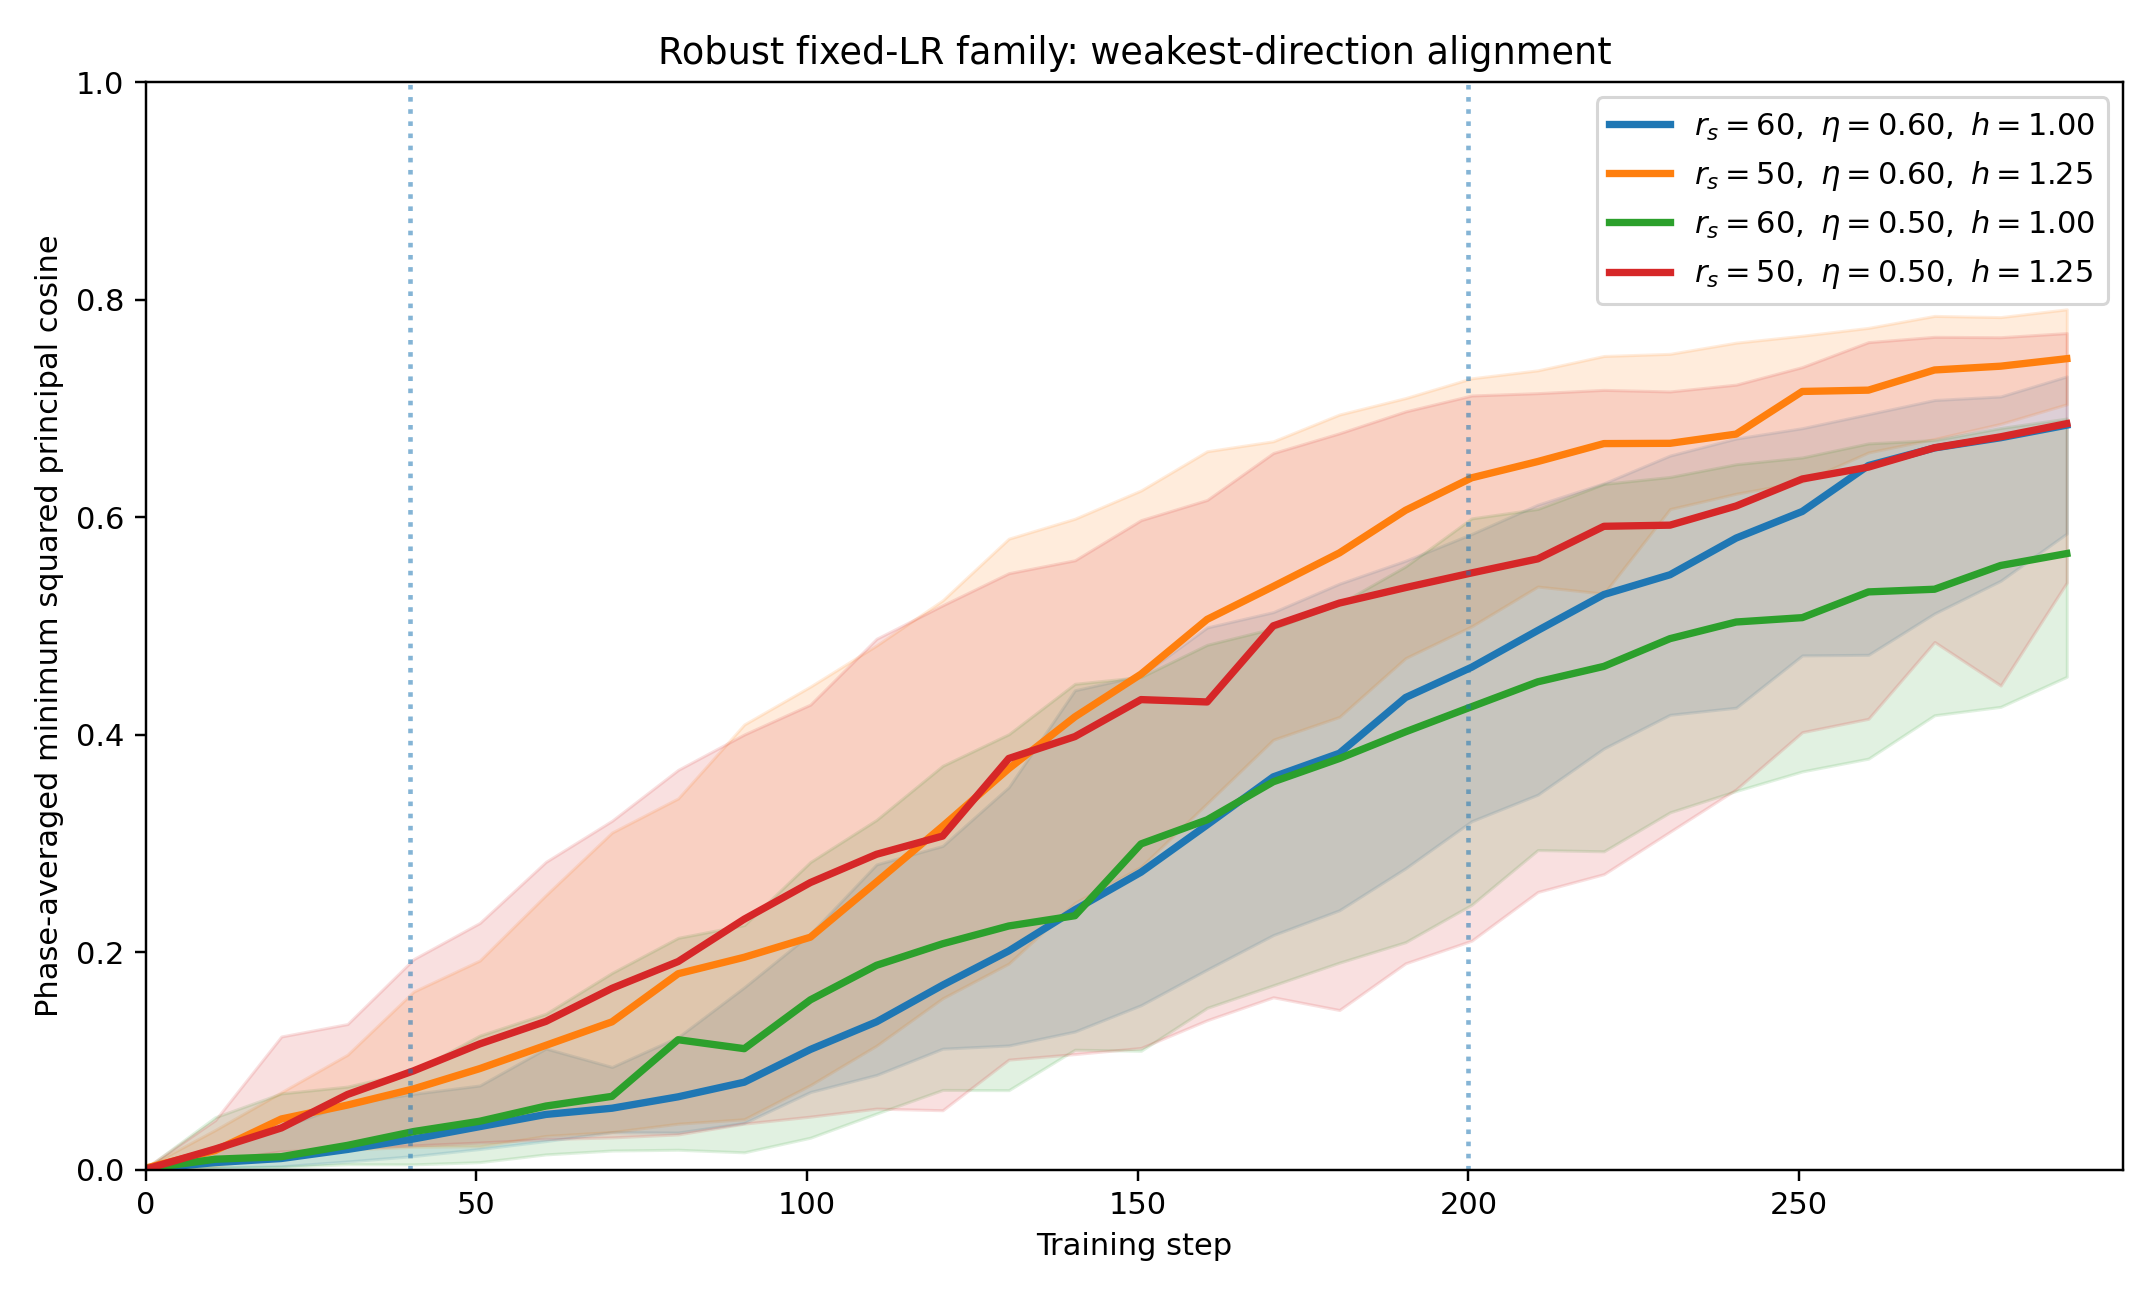

In [7]:
reference_dir = ROOT / "reference_outputs" / "robust_family_300"
reference_summary = reference_dir / "robust_family_summary.csv"
if reference_summary.exists():
    display(pd.read_csv(reference_summary)[[
        "config_id",
        "width",
        "learning_rate",
        "head_multiplier",
        "n_seeds",
        "median_loss_change",
        "median_mean_phaseavg_start",
        "median_mean_phaseavg_end",
        "median_mean_phaseavg_gain",
        "median_min_phaseavg_gain",
        "median_rho2",
        "median_r2",
        "strict_seeds",
    ]])
    for filename in [
        "robust_family_cycle_mean_loss.png",
        "robust_family_mean_alignment.png",
        "robust_family_min_alignment.png",
    ]:
        display(Image(filename=str(reference_dir / filename)))
else:
    print("Reference summary not found.")